In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sea

In [13]:
# Read the CSV file
df = pd.read_csv("CSV File/Website.csv", skiprows=1)

# Clean up column names by stripping whitespace
df.columns = df.columns.str.strip()

#you can use the DataFrame
print("Columns in the DataFrame:")
print(df.columns.tolist())
print("\nFirst few rows of data:")
df.head()

Columns in the DataFrame:
['Session primary channel group (Default channel group)', 'Date + hour (YYYYMMDDHH)', 'Users', 'Sessions', 'Engaged sessions', 'Average engagement time per session', 'Engaged sessions per user', 'Events per session', 'Engagement rate', 'Event count']

First few rows of data:


,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526667,0.607595,4.673333,0.480000,1402
1,Organic Social,2024041719,208,267,132,32.097378,0.634615,4.295880,0.494382,1147
2,Direct,2024041723,188,233,115,39.939914,0.611702,4.587983,0.493562,1069
3,Organic Social,2024041718,187,256,125,32.160156,0.668449,4.078125,0.488281,1044
4,Organic Social,2024041720,175,221,112,46.918552,0.640000,4.529412,0.506787,1001


In [14]:
df.columns = df.iloc[0]
df = df.drop(index = 0).reset_index(drop = True)
df.columns = ["Channel group" , "DateHour" ,  "Users","Sessions","Engaged sessions","Average engagement time per session","Engaged sessions per user" , "	Events per session	" , "Engagement rate" , "Event count"]
df.head()

,Channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,\tEvents per session\t,Engagement rate,Event count
0,Organic Social,2024041719,208,267,132,32.097378,0.634615,4.295880,0.494382,1147
1,Direct,2024041723,188,233,115,39.939914,0.611702,4.587983,0.493562,1069
2,Organic Social,2024041718,187,256,125,32.160156,0.668449,4.078125,0.488281,1044
3,Organic Social,2024041720,175,221,112,46.918552,0.640000,4.529412,0.506787,1001
4,Organic Social,2024041721,160,206,103,59.315534,0.643750,4.694175,0.500000,967


In [15]:
# Print all column names with their exact representation
print("Column names with their types and first few characters:")
for col in df.columns:
    print(f"'{col}' (type: {type(col)}, length: {len(col)}) - First 5 chars: '{col[:5]}'")

# Print the first few rows to see the data
print("\nFirst few rows of the DataFrame:")
df.head()

Column names with their types and first few characters:
'Channel group' (type: <class 'str'>, length: 13) - First 5 chars: 'Chann'
'DateHour' (type: <class 'str'>, length: 8) - First 5 chars: 'DateH'
'Users' (type: <class 'str'>, length: 5) - First 5 chars: 'Users'
'Sessions' (type: <class 'str'>, length: 8) - First 5 chars: 'Sessi'
'Engaged sessions' (type: <class 'str'>, length: 16) - First 5 chars: 'Engag'
'Average engagement time per session' (type: <class 'str'>, length: 35) - First 5 chars: 'Avera'
'Engaged sessions per user' (type: <class 'str'>, length: 25) - First 5 chars: 'Engag'
'	Events per session	' (type: <class 'str'>, length: 20) - First 5 chars: '	Even'
'Engagement rate' (type: <class 'str'>, length: 15) - First 5 chars: 'Engag'
'Event count' (type: <class 'str'>, length: 11) - First 5 chars: 'Event'

First few rows of the DataFrame:


,Channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,\tEvents per session\t,Engagement rate,Event count
0,Organic Social,2024041719,208,267,132,32.097378,0.634615,4.295880,0.494382,1147
1,Direct,2024041723,188,233,115,39.939914,0.611702,4.587983,0.493562,1069
2,Organic Social,2024041718,187,256,125,32.160156,0.668449,4.078125,0.488281,1044
3,Organic Social,2024041720,175,221,112,46.918552,0.640000,4.529412,0.506787,1001
4,Organic Social,2024041721,160,206,103,59.315534,0.643750,4.694175,0.500000,967


In [17]:
# Clean up column names
df.columns = df.columns.str.strip()

# Convert DateHour to datetime
df["DateHour"] = pd.to_datetime(df["DateHour"], format="%Y%m%d%H", errors="coerce")

# Convert numeric columns
numeric_cols = df.columns.drop(["Channel group", "DateHour"])
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

# Add hour column
df["Hour"] = df["DateHour"].dt.hour

# Show the results
df.head()

,Channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
1,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
2,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
3,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20
4,Organic Social,2024-04-17 21:00:00,160,206,103,59.315534,0.643750,4.694175,0.500000,967,21


**********Sessions and user Over time**********

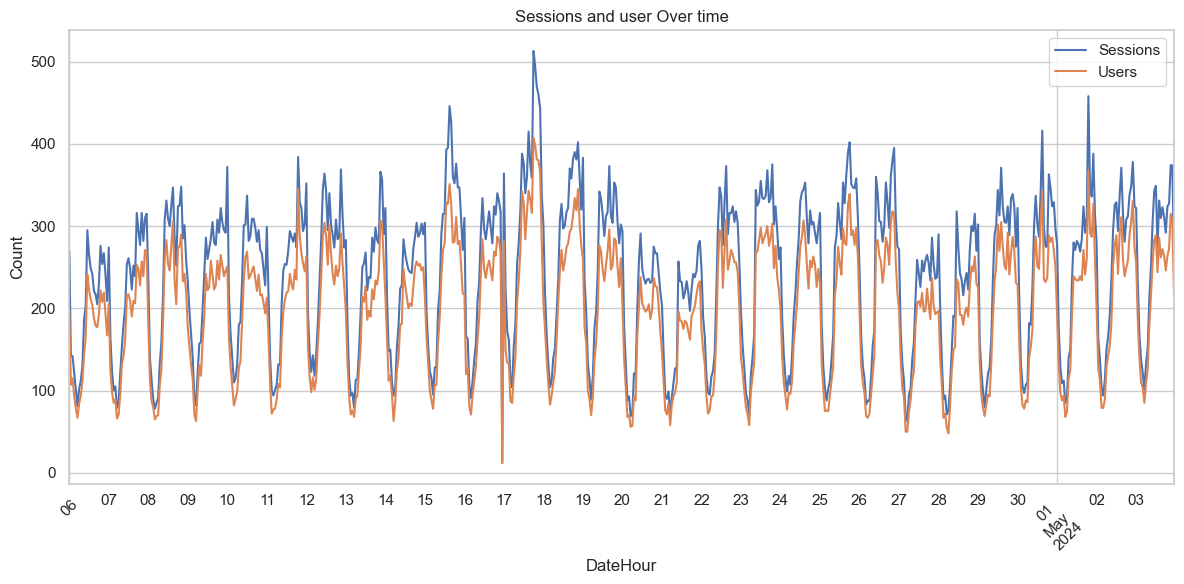

In [18]:
sea.set(style = "whitegrid")
plt.figure(figsize = (12,6))
df.groupby("DateHour")[["Sessions" , "Users"]].sum().plot(ax = plt.gca())
plt.title("Sessions and user Over time")
plt.xlabel("DateHour")
plt.ylabel("Count")
plt.legend(["Sessions" , "Users"])
plt.grid(True)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig("user Over time.png")
plt.show()

**********Users By Channel group**********

C:\Users\sumit\AppData\Local\Temp\ipykernel_1372\1930912287.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(data = df , x = "Channel group" , y = "Users" , estimator = np.sum , palette = "viridis")


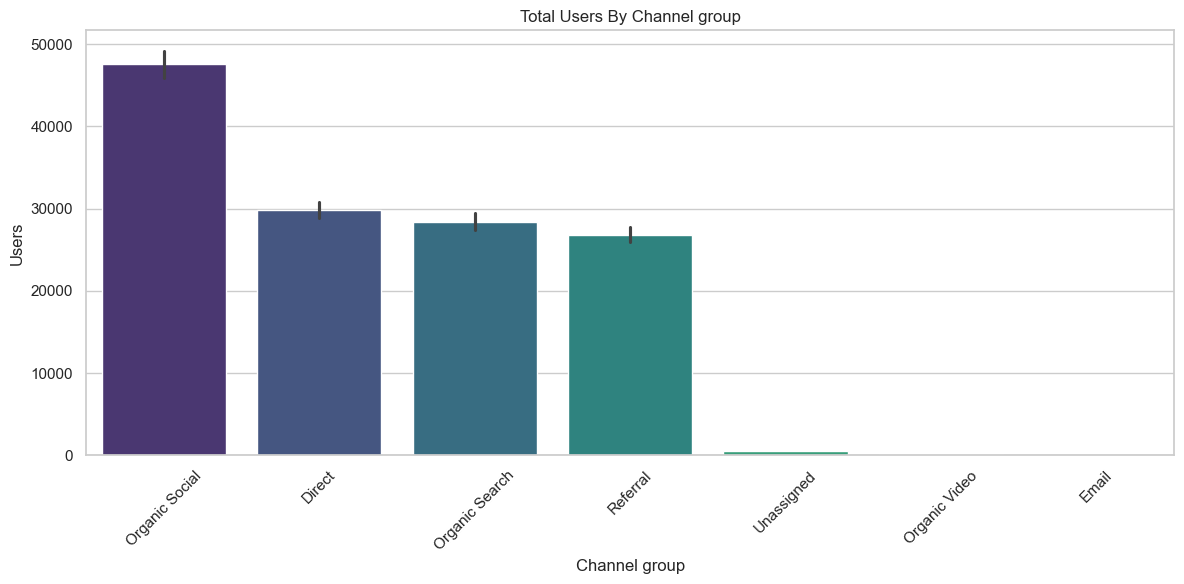

In [19]:
plt.figure(figsize=(12,6))
sea.barplot(data = df , x = "Channel group" , y = "Users" , estimator = np.sum , palette = "viridis")
plt.title("Total Users By Channel group")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig("Users By Channel.png")
plt.show()

**********Average engagement time by Channel group**********

C:\Users\sumit\AppData\Local\Temp\ipykernel_1372\4150676889.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.barplot(data=df , x = "Channel group" , y = "Average engagement time per session" , estimator = np.mean , palette = "magma")


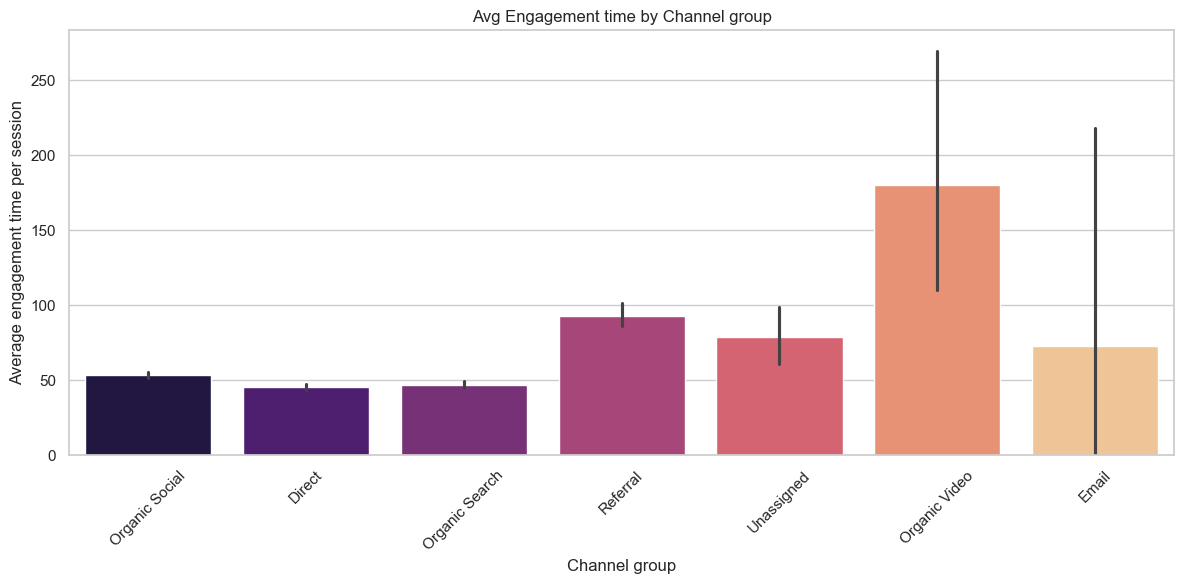

In [20]:
plt.figure(figsize = (12,6))
sea.barplot(data=df , x = "Channel group" , y = "Average engagement time per session" , estimator = np.mean , palette = "magma")
plt.title("Avg Engagement time by Channel group")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig("Avg Engagement time.png")
plt.show()

**********Engagement rate by Channel group**********

C:\Users\sumit\AppData\Local\Temp\ipykernel_1372\1230223421.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sea.boxplot(data=df,x="Channel group",y="Engagement rate",palette="coolwarm")


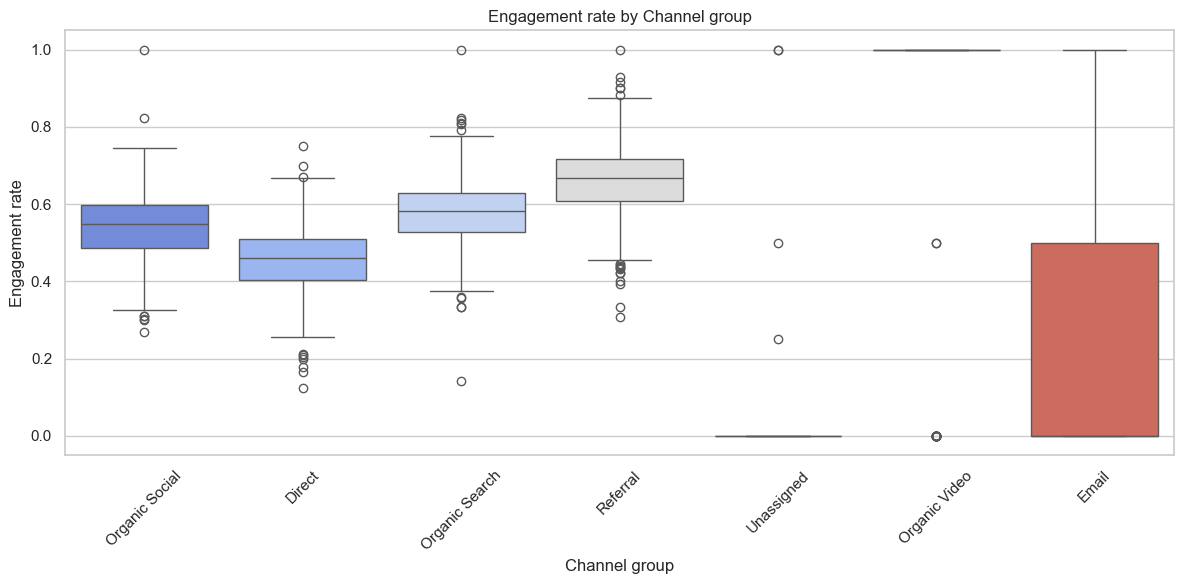

In [21]:
plt.figure(figsize = (12,6))
sea.boxplot(data=df,x="Channel group",y="Engagement rate",palette="coolwarm")
plt.title("Engagement rate by Channel group")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig("Engagement rate by Channel.png")
plt.show()

**********Engaged vs Non Engaged Sessions**********

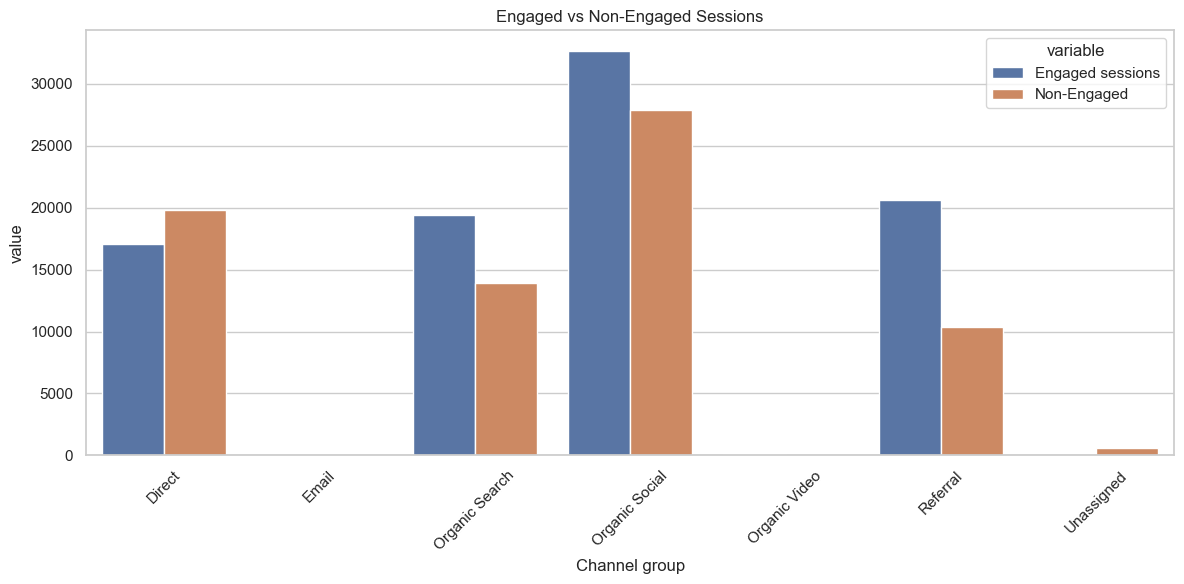

In [25]:
session_df = df.groupby("Channel group")[["Sessions" , "Engaged sessions"]].sum().reset_index()
session_df["Non-Engaged"] = session_df["Sessions"] - session_df["Engaged sessions"]

session_df_melted = session_df.melt(id_vars="Channel group",value_vars=["Engaged sessions", "Non-Engaged"])

plt.figure(figsize=(12,6))
sea.barplot(data=session_df_melted,x="Channel group",y="value" , hue="variable")
plt.title("Engaged vs Non-Engaged Sessions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Engaged vs Non-Engaged Sessions.png")
plt.show()


**********Traffic by Hour and Channel group**********

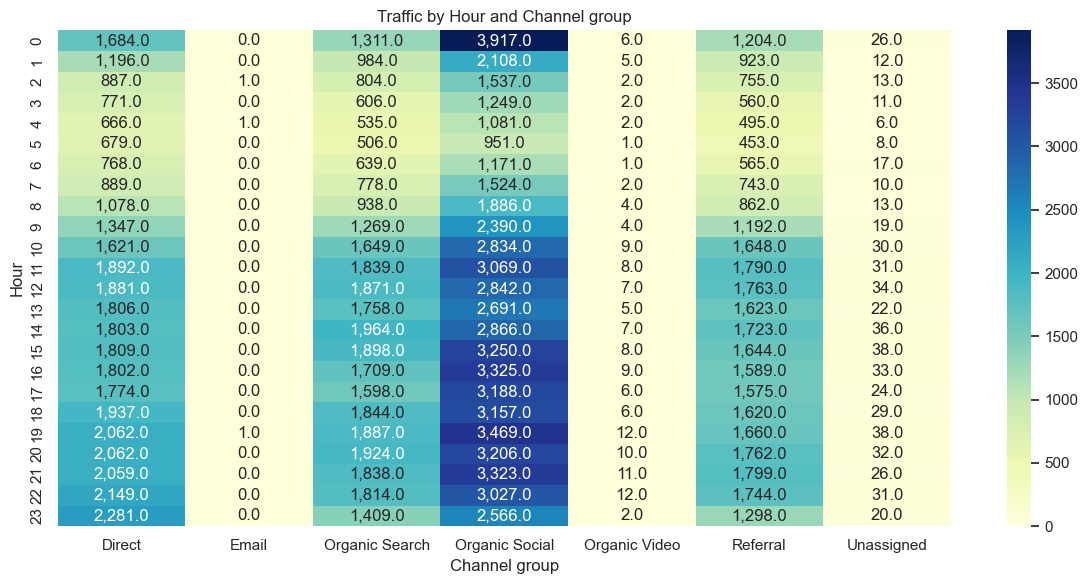

In [27]:
heatmap_data = df.groupby(["Hour" , "Channel group"])["Sessions"].sum().unstack().fillna(0)

plt.figure(figsize = (12,6))
sea.heatmap(data = heatmap_data , cmap = "YlGnBu" , annot = True , fmt = ",")
plt.title("Traffic by Hour and Channel group")
plt.xlabel("Channel group")
plt.ylabel("Hour")
plt.tight_layout()
plt.savefig("Traffic by Hour and Channel.png")
plt.show()

In [28]:
df.head()

,Channel group,DateHour,Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
1,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
2,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
3,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20
4,Organic Social,2024-04-17 21:00:00,160,206,103,59.315534,0.643750,4.694175,0.500000,967,21


**********Engagement Rates Vs Sessions Over time**********

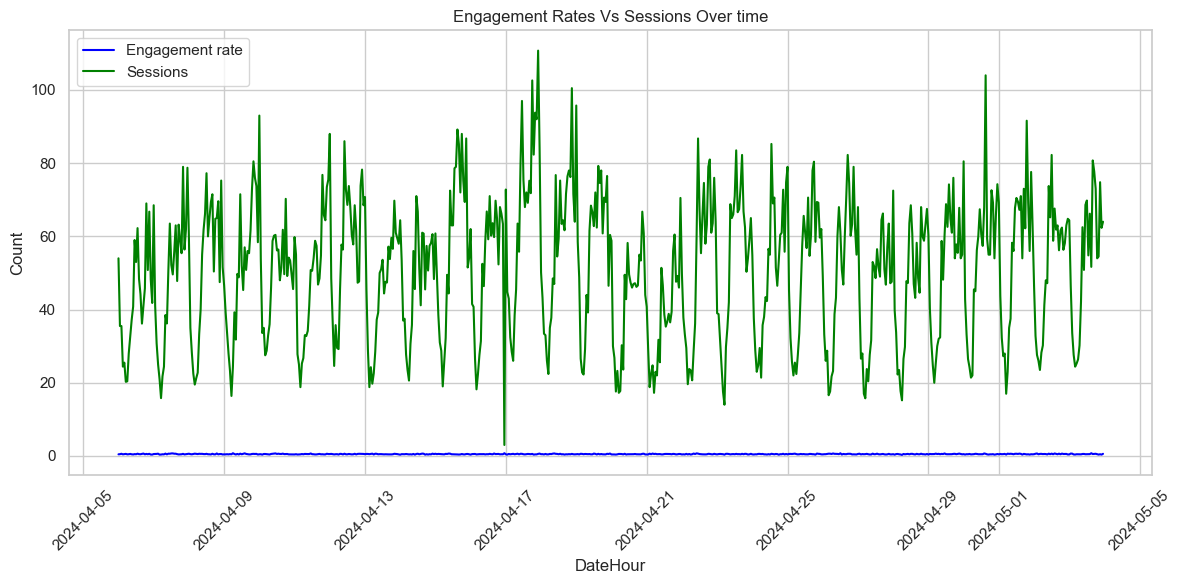

In [30]:
df_plot = df.groupby("DateHour")[["Engagement rate" , "Sessions"]].mean().reset_index()

plt.figure(figsize = (12,6))
plt.plot(df_plot["DateHour"] , df_plot["Engagement rate"] , label = "Engagement rate" , color = "blue")
plt.plot(df_plot["DateHour"] , df_plot["Sessions"] , label = "Sessions" , color = "green")
plt.title("Engagement Rates Vs Sessions Over time")
plt.xlabel("DateHour")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig("Engagement Rates Vs Sessions Over time.png")
plt.show()

**********Correlation Heatmap of Key Metrics**********

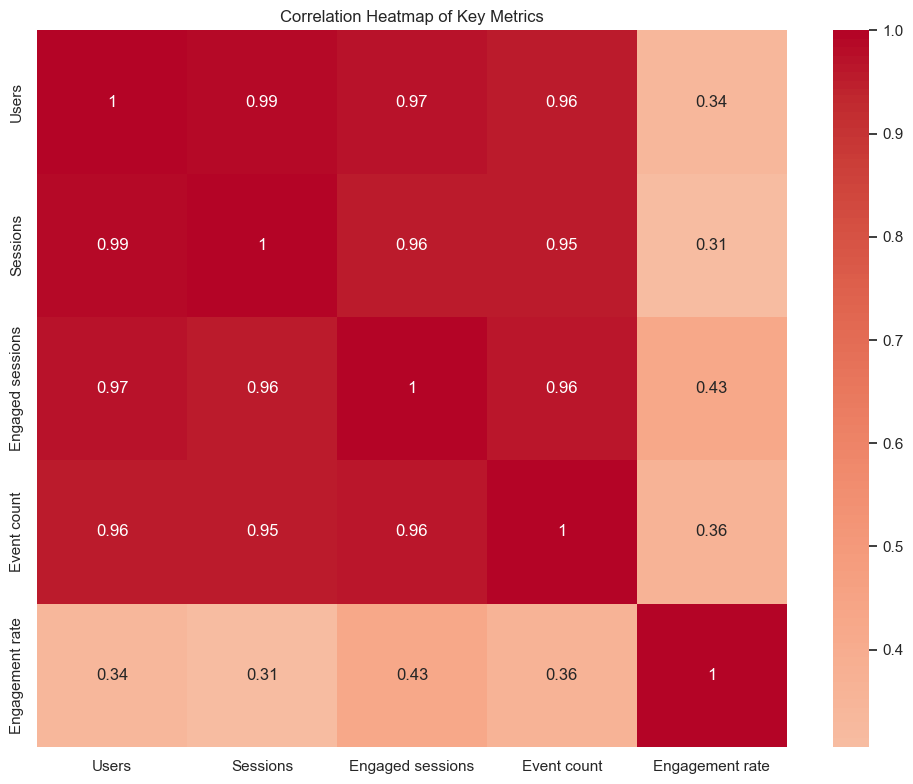

In [32]:
# Correlation between metrics
plt.figure(figsize=(10, 8))
corr = df[['Users', 'Sessions', 'Engaged sessions', 'Event count', 'Engagement rate']].corr()
sea.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Key Metrics')
plt.tight_layout()
plt.savefig('Correlation_Heatmap.png')
plt.show()

**********Top Performing Time Slots**********

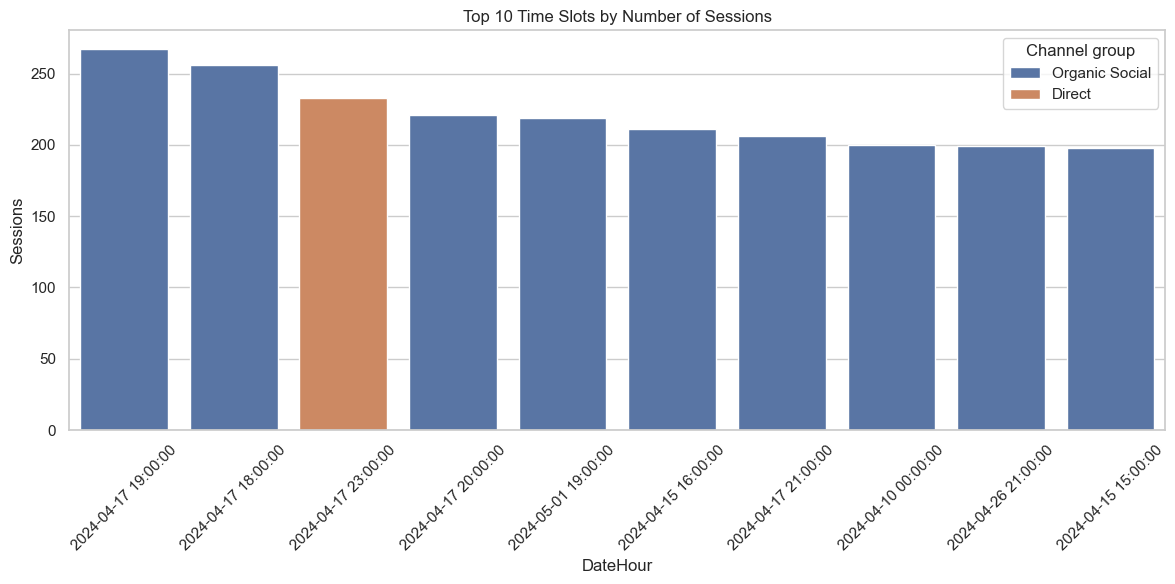

In [34]:
# Top performing time slots
top_slots = df.nlargest(10, 'Sessions')[['DateHour', 'Channel group', 'Sessions', 'Engagement rate']]
plt.figure(figsize=(12, 6))
sea.barplot(data=top_slots, x='DateHour', y='Sessions', hue='Channel group')
plt.title('Top 10 Time Slots by Number of Sessions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Top_Performing_Time_Slots.png')
plt.show()

**********Hourly Engagement by Channel**********

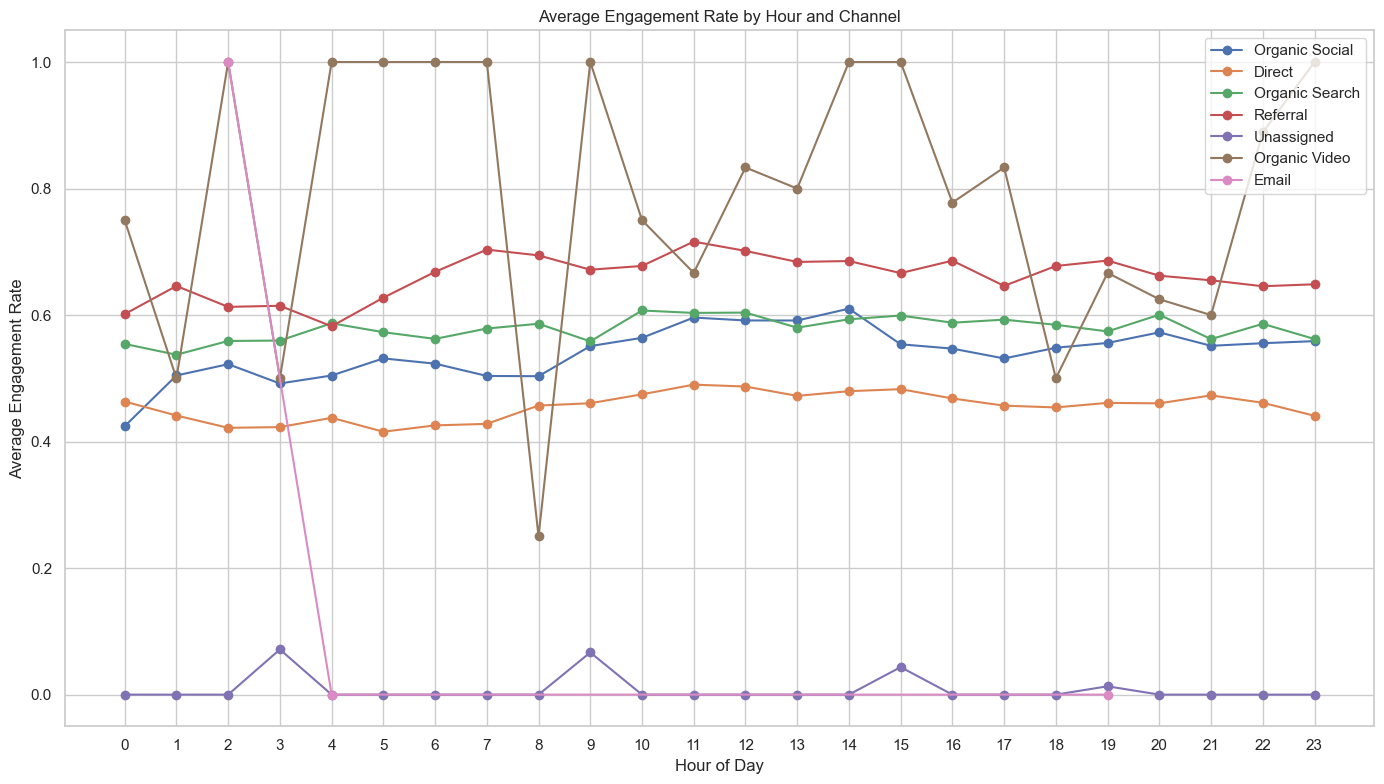

In [36]:
# Hourly engagement patterns by channel
plt.figure(figsize=(14, 8))
for channel in df['Channel group'].unique():
    channel_data = df[df['Channel group'] == channel].groupby('Hour')['Engagement rate'].mean()
    plt.plot(channel_data.index, channel_data.values, label=channel, marker='o')
plt.title('Average Engagement Rate by Hour and Channel')
plt.xlabel('Hour of Day')
plt.ylabel('Average Engagement Rate')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('Hourly_Engagement_by_Channel.png')
plt.show()

**********Channel Performance Over Time**********

<Figure size 1400x800 with 0 Axes>

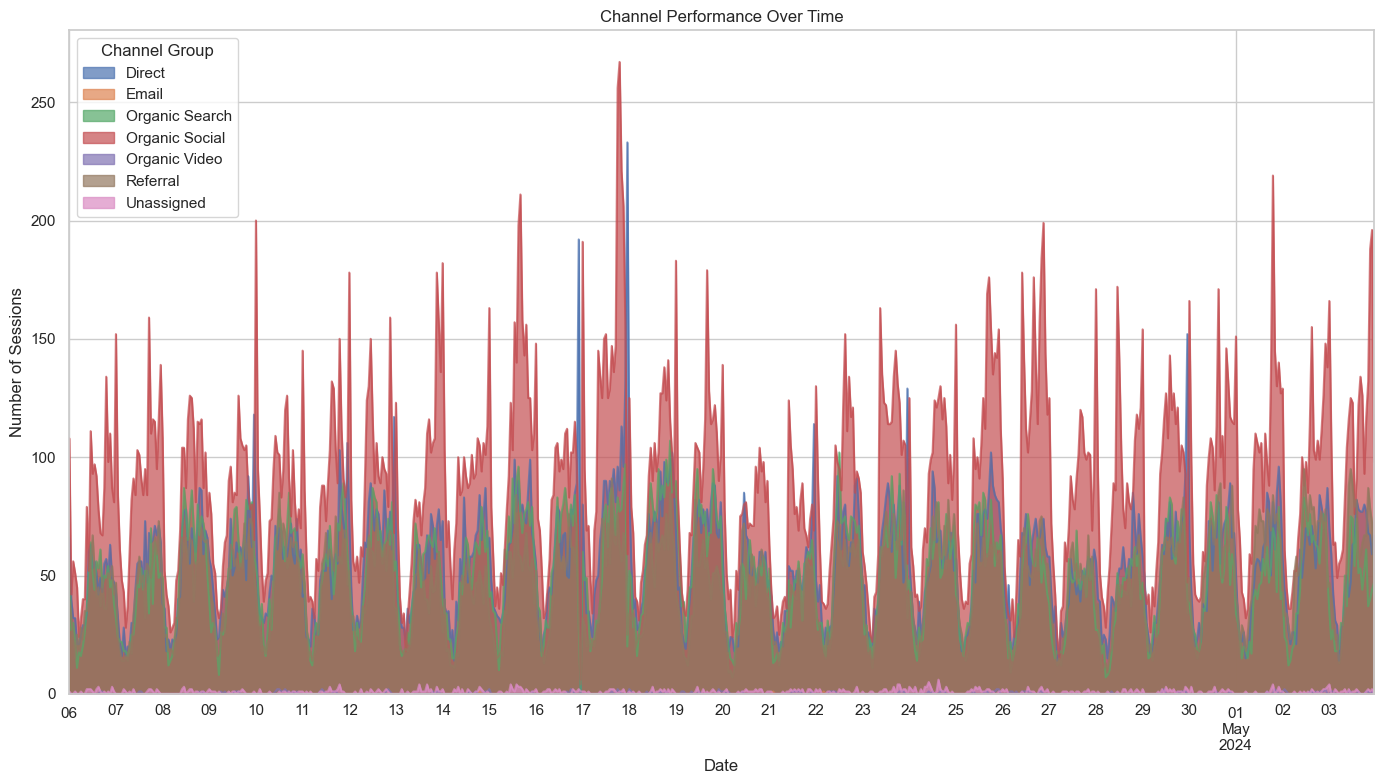

In [38]:
# Channel performance trend - area chart
plt.figure(figsize=(14, 8))
channel_trend = df.groupby(['DateHour', 'Channel group'])['Sessions'].sum().unstack().fillna(0)
channel_trend.plot.area(stacked=False, alpha=0.7, figsize=(14, 8))
plt.title('Channel Performance Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Sessions')
plt.legend(title='Channel Group')
plt.grid(True)
plt.tight_layout()
plt.savefig('Channel_Performance_Area_Chart.png')
plt.show()

**********Top Performing Days of Week**********


C:\Users\sumit\AppData\Local\Temp\ipykernel_1372\329424776.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sea.barplot(


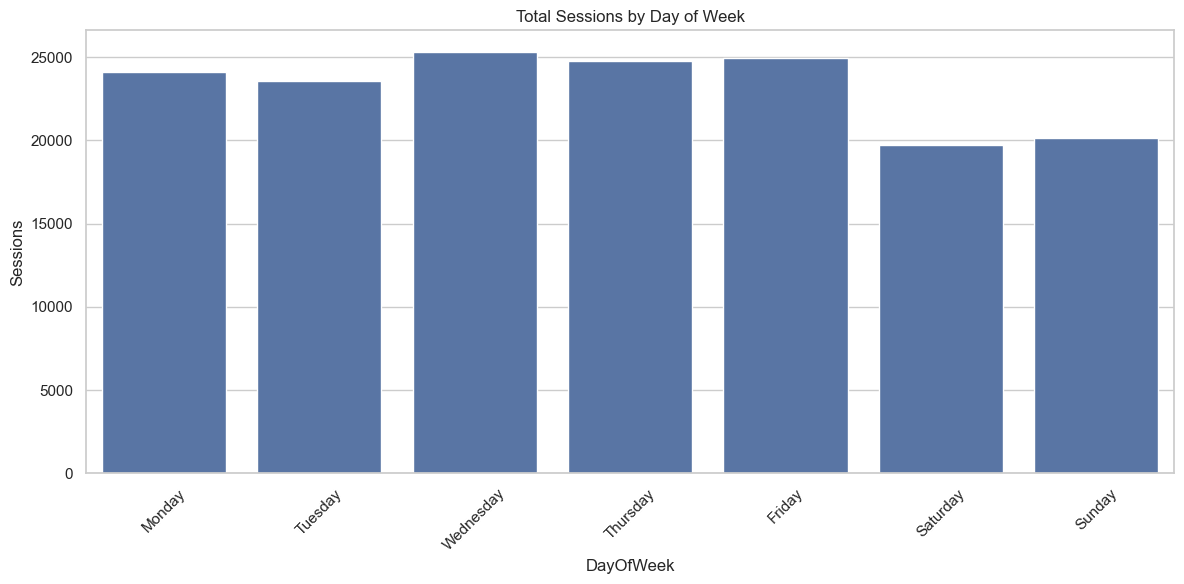

In [41]:
# Add day of week column
df['DayOfWeek'] = df['DateHour'].dt.day_name()

# Top performing days
plt.figure(figsize=(12, 6))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sea.barplot(
    data=df,
    x='DayOfWeek',
    y='Sessions',
    order=day_order,
    ci=None,
    estimator=sum
)
plt.title('Total Sessions by Day of Week')
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('Sessions_by_DayOfWeek.png')
plt.show()